<a href="https://colab.research.google.com/github/RodrigoLMarques/calculo-numerico-unifesp/blob/main/atividade_1/cn_atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividade 1

Nome: Luan Groppo Viana

RA: 17710

Realizou: A, B

Nome: Rodrigo Lopes Marques

RA: 180385

Realizou: C

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def trunca(x, n):
    return math.trunc(10**n * x) / 10**n

In [ ]:
#PARTE A
values = [3.14159265, 98.76543, 0.00498765]
names = ['x1','x2','x3']
rows=[]
for name, x in zip(names, values):
    ea_t = []
    ea_r = []
    for n in range(5):
        f = 10 ** n
        trunc = trunca(x, n)
        rnd = round(x, n)
        Ea_t = abs(x - trunc)
        Er_t = Ea_t / abs(x)
        Ep_t = 100 * Er_t

        Ea_r = abs(x - rnd)
        Er_r = Ea_r / abs(x)
        Ep_r = 100 * Er_r

        ea_t.append(Ea_t)
        ea_r.append(Ea_r)

        rows.append([name, n, 'Truncamento', trunc, Ea_t, Er_t, Ep_t])
        rows.append([name, n, 'Arredondamento', rnd, Ea_r, Er_r, Ep_r])

    plt.figure()
    plt.semilogy(range(5), ea_t, 'o-', label = 'Truncamento')
    plt.semilogy(range(5), ea_r, 's-', label = 'Arredondamento')
    plt.xlabel('n')
    plt.ylabel('Ea')
    plt.title(f'Erro absoluto - {name}')
    plt.grid(True)
    plt.legend()
    plt.savefig(f'parteA_{name}.png', dpi = 300, bbox_inches = 'tight')
    plt.close()

pd.DataFrame(rows,columns=['valor', 'n', 'metodo', 'aprox', 'Ea', 'Er', 'E%']).to_csv('parteA_tabela.csv',index = False)

#RESPOSTA PERGUNTA:
#Sim, o arredondamento sempre apresenta um erro menor ou igual que o truncamento.
#Isso ocorre pois o arredondamento escolhe a representação mais próxima do número
#com N números significativos, enquanto o truncamento apenas descarta os
#dígitos após a enesima casa decimal, sem considerar sua influência na aproximação

In [ ]:
#PARTE B

press = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
round_i = np.rint(press)
trunc_i = np.trunc(press)

ref_mean = press.mean()

stats = []
for nome, serie in [('Original', press), ('Arredondado', round_i), ('Truncado', trunc_i)]:
    mean = np.mean(serie)
    ea = abs(mean - ref_mean)
    er = ea / ref_mean
    ep = 100 * er
    stats.append([
        nome, mean, np.min(serie), np.max(serie),
        np.max(serie) - np.min(serie),
        np.std(serie, ddof = 1), ea, er, ep
    ])

pd.DataFrame(stats, columns = ['Serie', 'Media', 'Min', 'Max', 'Amplitude', 'DP', 'Ea', 'Er', 'E%']).to_csv('parteB_estatisticas.csv', index = False)

plt.figure(figsize = (9, 4))
plt.plot(press, 'o-', label = 'Original')
plt.plot(round_i, 's-', label = 'Arred.')
plt.plot(trunc_i, '^-', label = 'Trunc.')
plt.legend()
plt.grid(True)
plt.savefig('parteB_medicoes.png', dpi = 300)
plt.close()

erro_abs = [x[6] for x in stats]
plt.figure(figsize=(7, 4))
plt.bar(["Original", "Arredondado", "Truncado"],
        erro_abs,
        color=["green", "orange", "red"])
plt.title("Erro Absoluto da Média em Relação à Série Original")
plt.xlabel("Séries")
plt.ylabel("Erro Absoluto")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_erro_absoluto.png', dpi=300, bbox_inches='tight')
plt.close()


In [ ]:
plt.title('Meu Gráfico de Barras')
plt.xlabel('Categorias')
plt.ylabel('Valores')

# Mostrar o gráfico
plt.show()# Parte D

r = 50 #nm
L = 10 #μm
mi = 3.5e−3 #Pa s
d_p = 5000  #Pa.

x = 2.2e-2

print (x)

SyntaxError: invalid decimal literal (2196844647.py, line 5)

## 5. Parte C - vazão em um tubo de pequeno diâmetro

In [ ]:
# C.1

def Q(r_mm, mi, dp, L=0.20):
    r = r_mm * 1e-3
    return math.pi * r**4 * dp / (8 * mi * L)

r0 = 0.80 # mm
L = 0.20 # m
mi0 = 3.5e-3 # Pas
dp0 = 1200.0 # Pa

Qref = Q(r0, mi0, dp0)

casos = [
    ("todos os valores", r0, mi0, dp0),
    ("r arredondado", round(r0, 1), mi0, dp0),
    ("r truncado", trunca(r0, 1), mi0, dp0),
    ("mi arredondada", r0, round(mi0, 3), dp0),
    ("mi truncada", r0, trunca(mi0, 3), dp0),
    ("dp arredondada", r0, mi0, round(dp0, -2)),
    ("dp truncada", r0, mi0, trunca(dp0, -2)),
    ("todas arredondadas", round(r0, 1), round(mi0, 3), round(dp0, -2)),
    ("todas truncadas", trunca(r0, 1), trunca(mi0, 3), trunca(dp0, -2)),
]

print(f"Qref = {Qref:.6e} m^3/s")
for nome, r, mi, dp in casos:
    q  = Q(r, mi, dp)
    ea = abs(q - Qref)
    er = ea / abs(Qref)
    ep = er * 100
    print(f"{nome:<20} Q={q:.5e}  erro absoluto={ea:.3e}  erro relativo={er:.3e}  erro percentual={ep:.4f}%")


Qref = 2.757421e-07 m^3/s
todos os valores     Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
r arredondado        Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
r truncado           Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
mi arredondada       Q=2.41274e-07  erro absoluto=3.447e-08  erro relativo=1.250e-01  erro percentual=12.5000%
mi truncada          Q=3.21699e-07  erro absoluto=4.596e-08  erro relativo=1.667e-01  erro percentual=16.6667%
dp arredondada       Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
dp truncada          Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
todas arredondadas   Q=2.41274e-07  erro absoluto=3.447e-08  erro relativo=1.250e-01  erro percentual=12.5000%
todas truncadas      Q=3.21699e-07  erro absoluto=4.596e-08  erro relativo=1.667e-01  erro 

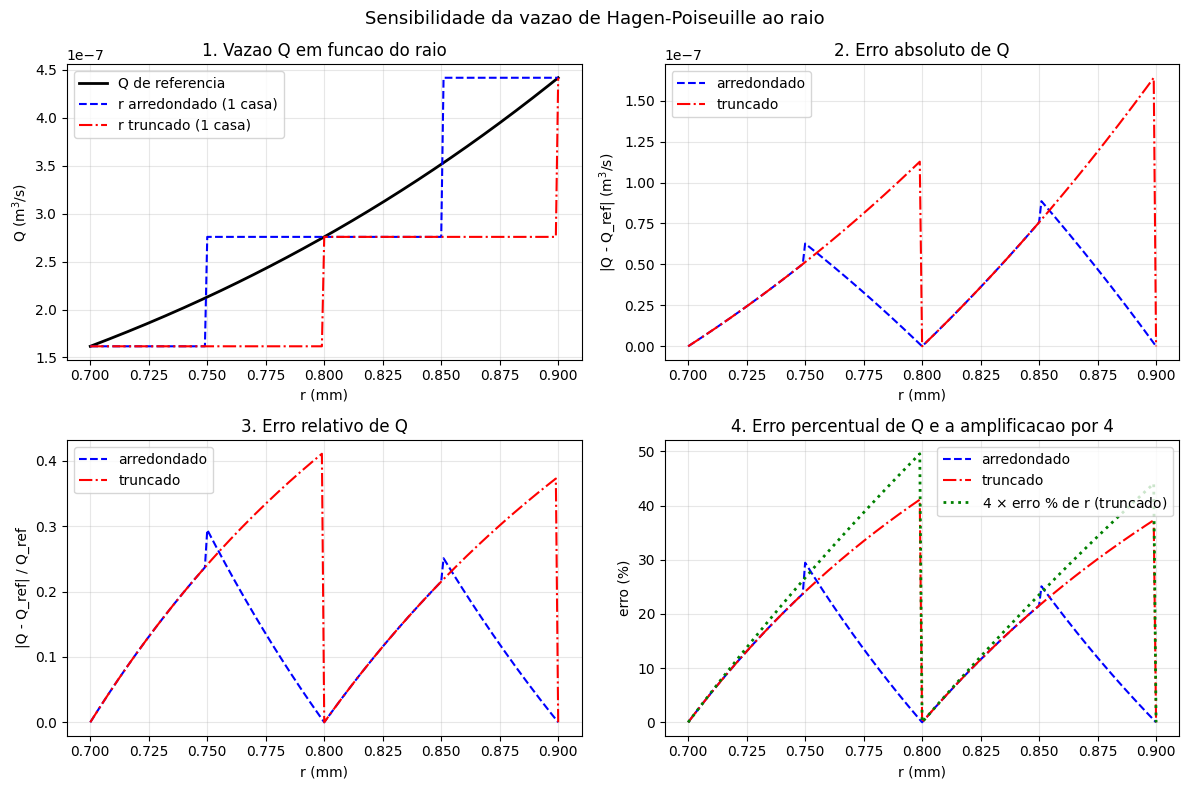

In [ ]:
# C.2

r_inicial = 0.70
r_final = 0.90

# array de valores dos raios
raios       = np.round(np.linspace(r_inicial, r_final, 201), 10)
raios_arr   = np.round(raios, 1)
raios_trunc = np.trunc(raios * 10) / 10

# array dos valores de Q para cada raio
Q_ref   = Q(raios, mi0, dp0)
Q_arr   = Q(raios_arr, mi0, dp0)
Q_trunc = Q(raios_trunc, mi0, dp0)

# array dos erros absoluto, relativo e percentual
ea_arr = abs(Q_arr - Q_ref)
ea_trunc = abs(Q_trunc - Q_ref)

er_arr = ea_arr / Q_ref
er_trunc = ea_trunc / Q_ref

ep_arr = er_arr * 100
ep_trunc = er_trunc * 100

# erro percentual do proprio raio truncado
ep_r_trunc = 100 * (abs(raios_trunc - raios) / raios)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Q em funcao de r
ax[0,0].plot(raios, Q_ref, 'k-', lw=2, label='Q de referencia')
ax[0,0].plot(raios, Q_arr, 'b--', lw=1.5, label='r arredondado (1 casa)')
ax[0,0].plot(raios, Q_trunc, 'r-.', lw=1.5, label='r truncado (1 casa)')
ax[0,0].set_xlabel('r (mm)'); ax[0,0].set_ylabel('Q (m$^3$/s)')
ax[0,0].set_title('1. Vazao Q em funcao do raio')

# 2. erro absoluto
ax[0,1].plot(raios, ea_arr, 'b--', lw=1.5, label='arredondado')
ax[0,1].plot(raios, ea_trunc, 'r-.', lw=1.5, label='truncado')
ax[0,1].set_xlabel('r (mm)'); ax[0,1].set_ylabel('|Q - Q_ref| (m$^3$/s)')
ax[0,1].set_title('2. Erro absoluto de Q')

# 3. erro relativo
ax[1,0].plot(raios, er_arr, 'b--', lw=1.5, label='arredondado')
ax[1,0].plot(raios, er_trunc, 'r-.', lw=1.5, label='truncado')
ax[1,0].set_xlabel('r (mm)'); ax[1,0].set_ylabel('|Q - Q_ref| / Q_ref')
ax[1,0].set_title('3. Erro relativo de Q')

# 4. erro percentual, comparado com 4x o erro relativo do raio
ax[1,1].plot(raios, ep_arr, 'b--', lw=1.5, label='arredondado')
ax[1,1].plot(raios, ep_trunc, 'r-.', lw=1.5, label='truncado')
ax[1,1].plot(raios, 4*ep_r_trunc, 'g:', lw=2, label=r'4 $\times$ erro % de r (truncado)')
ax[1,1].set_xlabel('r (mm)'); ax[1,1].set_ylabel('erro (%)')
ax[1,1].set_title('4. Erro percentual de Q e a amplificacao por 4')

for eixo in ax.flat:
    eixo.legend()
    eixo.grid(alpha=0.3)

fig.suptitle('Sensibilidade da vazao de Hagen-Poiseuille ao raio', fontsize=13)
fig.tight_layout()
plt.show()


## Explicação do porque o erro no raio é amplificado na vazão
Na equação de Hagen-Poiseuille, a vazão é proporcional ao raio elevado à quarta potência, então um erro relativo no raio entra na conta quatro vezes. Se o raio erra 1%, a vazão erra cerca de 4%.